# Activation Geometry

Clone the repo into Kaggle, validate that the locally generated Gemini-backed prompt set and split manifests are present, then measure last-token residual activations on the discovery split.

In [4]:
import os
import subprocess
import sys
from pathlib import Path

try:
    from kaggle_secrets import UserSecretsClient
except ImportError:
    UserSecretsClient = None


def read_secret(name: str) -> str:
    if UserSecretsClient is not None:
        try:
            return UserSecretsClient().get_secret(name).strip()
        except Exception:
            pass
    return os.environ.get(name, "").strip()


REPO_URL = read_secret("FRS_REPO_URL")
HF_TOKEN = read_secret("HF_TOKEN")
REPO_DIR = Path("/kaggle/working/false-refusal-suppression")

if not REPO_URL:
    raise RuntimeError("Set FRS_REPO_URL in Kaggle Secrets before running this notebook.")

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN
    os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-e", f"{REPO_DIR}[train,dev]"], check=True)

os.chdir(REPO_DIR)
src_path = REPO_DIR / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(REPO_DIR)
print("HF token loaded:", bool(HF_TOKEN))

From https://github.com/aaliyan1230/false-refusal-suppression
   4f6daba..7ea9fde  main       -> origin/main


Updating 4f6daba..7ea9fde
Fast-forward
 notebooks/00_data_audit.ipynb              | 714 ++++++++++++++++++++++++++++-
 notebooks/10_activation_geometry.ipynb     |  34 +-
 notebooks/20_edit_search.ipynb             |  34 +-
 notebooks/30_eval_and_error_analysis.ipynb |  34 +-
 scripts/measure_activations.py             |  71 +--
 5 files changed, 817 insertions(+), 70 deletions(-)
Obtaining file:///kaggle/working/false-refusal-suppression
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for false-refusal-suppression (pyproject

In [2]:
from pathlib import Path

MODEL_ID = "Qwen/Qwen3-4B"
PILOT_PROMPTS = Path("data/processed/prompts/pilot_prompts_gemini.jsonl")
SPLIT_DIR = Path("data/processed/splits/pilot_gemini")
ACTIVATION_ARTIFACT = Path("artifacts/activations/qwen3_gemini_pilot_discovery.json")
DIRECTION_ARTIFACT = Path("artifacts/directions/qwen3_gemini_pilot_borderline_vs_easy.json")

required_paths = [PILOT_PROMPTS, SPLIT_DIR / "discovery.jsonl"]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing prebuilt local data artifacts. Generate and commit them locally before using Kaggle: " + ", ".join(missing)
    )

print(MODEL_ID)
print(PILOT_PROMPTS)
print(ACTIVATION_ARTIFACT)
print(DIRECTION_ARTIFACT)

Qwen/Qwen3-4B
data/processed/prompts/pilot_prompts_gemini.jsonl
artifacts/activations/qwen3_gemini_pilot_discovery.json
artifacts/directions/qwen3_gemini_pilot_borderline_vs_easy.json


In [5]:
subprocess.run(
    [
        sys.executable,
        "scripts/measure_activations.py",
        "--model-id",
        MODEL_ID,
        "--split-path",
        str(SPLIT_DIR / "discovery.jsonl"),
        "--output",
        str(ACTIVATION_ARTIFACT),
        "--capture-default-modules",
        "--max-module-captures",
        "12",
    ],
    check=True,
 )

subprocess.run(
    [
        sys.executable,
        "scripts/compute_directions.py",
        "--activations",
        str(ACTIVATION_ARTIFACT),
        "--source-group-a",
        "benign_borderline",
        "--source-group-b",
        "benign_easy",
        "--output",
        str(DIRECTION_ARTIFACT),
    ],
    check=True,
 )

2026-04-14 16:37:34.134568: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776184654.344592     266 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776184654.406639     266 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776184654.917394     266 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776184654.917446     266 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776184654.917452     266 computation_placer.cc:177] computation placer alr

artifacts/activations/qwen3_gemini_pilot_discovery.json
artifacts/directions/qwen3_gemini_pilot_borderline_vs_easy.json


CompletedProcess(args=['/usr/bin/python3', 'scripts/compute_directions.py', '--activations', 'artifacts/activations/qwen3_gemini_pilot_discovery.json', '--source-group-a', 'benign_borderline', '--source-group-b', 'benign_easy', '--output', 'artifacts/directions/qwen3_gemini_pilot_borderline_vs_easy.json'], returncode=0)

,group_counts,hidden_size,layer_names,module_names,num_examples
0,"{'benign_borderline': 16, 'benign_easy': 16, '...",2560,"[layer_00, layer_01, layer_02, layer_03, layer...","[model.layers.0.mlp.down_proj, model.layers.0....",64


,name,score
0,layer_17,0.710643
1,layer_22,0.701876
2,layer_19,0.701698
3,layer_20,0.698059
4,layer_18,0.695392
5,layer_21,0.688137
6,layer_16,0.687749
7,layer_23,0.652682
8,layer_24,0.641905
9,layer_14,0.638998


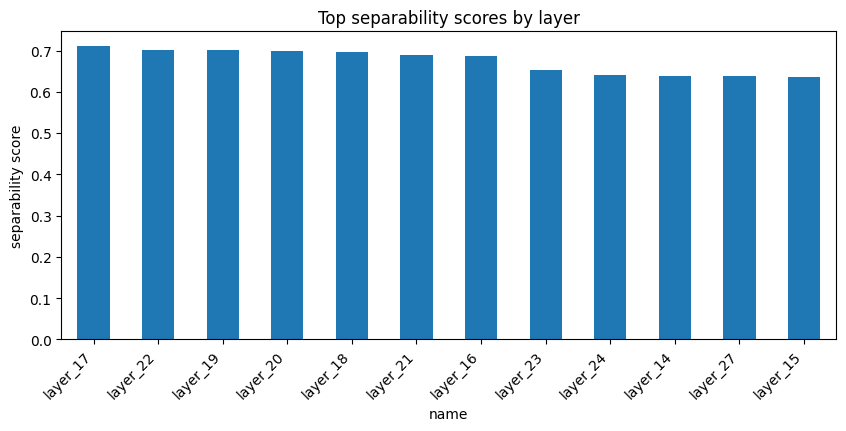

In [6]:
import json
import matplotlib.pyplot as plt
import pandas as pd

with open(ACTIVATION_ARTIFACT, "r", encoding="utf-8") as handle:
    activation_artifact = json.load(handle)

with open(DIRECTION_ARTIFACT, "r", encoding="utf-8") as handle:
    direction_artifact = json.load(handle)

ranked_layers = pd.DataFrame(direction_artifact["ranked_layers"])
display(pd.DataFrame([activation_artifact["summary"]]))
display(ranked_layers.head(12))

if not ranked_layers.empty:
    ax = ranked_layers.head(12).plot.bar(
        x="name",
        y="score",
        figsize=(10, 4),
        legend=False,
        title="Top separability scores by layer",
    )
    ax.set_ylabel("separability score")
    plt.xticks(rotation=45, ha="right")
    plt.show()